# Phase 1 — Data Exploration
**AAI-511 · Composer Identification via Deep Learning**

File counts per composer across train/dev/test splits, average MIDI duration per composer, and MIDI file validation.

In [37]:
# Import libraries
import os
import pretty_midi
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


In [38]:
# 1. File Counts per Composer
DATA_DIR = 'data'
COMPOSERS = ['bach', 'beethoven', 'chopin', 'mozart']
splits = ['train', 'dev', 'test']
records = []

for split in splits:
    split_dir = os.path.join(DATA_DIR, split)
    for composer in sorted(os.listdir(split_dir)):
        if composer not in COMPOSERS:
            continue
        composer_dir = os.path.join(split_dir, composer)
        if not os.path.isdir(composer_dir):
            continue
        files = [f for f in os.listdir(composer_dir) if f.endswith('.mid')]
        records.append({'split': split, 'composer': composer.capitalize(), 'count': len(files)})

df = pd.DataFrame(records)
pivot = df.pivot(index='composer', columns='split', values='count').fillna(0).astype(int)
pivot['total'] = pivot.sum(axis=1)
pivot = pivot[['train', 'dev', 'test', 'total']]
print(pivot.to_string())

split      train  dev  test  total
composer                          
Bach          42    4     4     50
Beethoven     42    4     4     50
Chopin        41    4     4     49
Mozart        41    4     4     49


In [39]:
# 2. Average Duration per Composer (train set)
duration_records = []

for composer in sorted(os.listdir(os.path.join(DATA_DIR, 'train'))):
    if composer not in COMPOSERS:
        continue
    composer_dir = os.path.join(DATA_DIR, 'train', composer)
    if not os.path.isdir(composer_dir):
        continue
    for fname in os.listdir(composer_dir):
        if not fname.endswith('.mid'):
            continue
        fpath = os.path.join(composer_dir, fname)
        try:
            midi = pretty_midi.PrettyMIDI(fpath)
            duration_records.append({'composer': composer.capitalize(), 'duration_s': midi.get_end_time()})
        except Exception:
            pass

df_dur = pd.DataFrame(duration_records)
summary = df_dur.groupby('composer')['duration_s'].agg(
    mean='mean', median='median', min='min', max='max', files='count'
).round(1)
summary['mean_min'] = (summary['mean'] / 60).round(2)
print(summary[['files', 'mean', 'mean_min', 'median', 'min', 'max']].to_string())

/Users/mgarzon/Desktop/USD/AAI511/Assigments/Assignment2/.venv/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


           files   mean  mean_min  median   min     max
composer                                               
Bach          42  280.4      4.67   117.9  61.7  1047.9
Beethoven     42  251.7      4.19   162.4  27.0   819.8
Chopin        41  274.8      4.58   189.0  40.9  2130.7
Mozart        41  503.4      8.39   466.9  95.0  1633.0


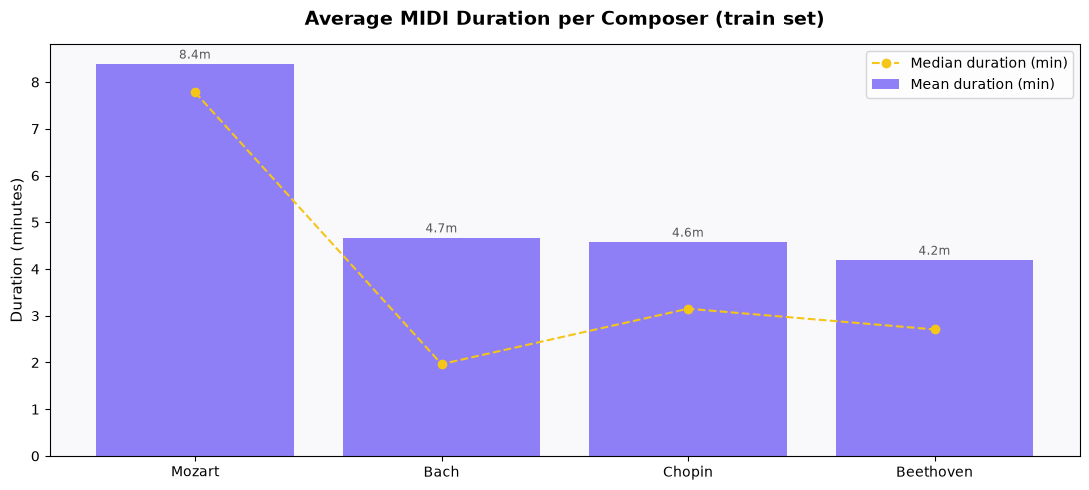

In [40]:
fig, ax = plt.subplots(figsize=(11, 5))

order = summary['mean'].sort_values(ascending=False).index.tolist()
means = summary.loc[order, 'mean'] / 60
medians = summary.loc[order, 'median'] / 60

ax.bar(order, means, color='#7c6af7', alpha=0.85, label='Mean duration (min)')
ax.plot(order, medians, 'o--', color='#f5c518', linewidth=1.5, markersize=6, label='Median duration (min)')

for i, (comp, val) in enumerate(zip(order, means)):
    ax.text(i, val + 0.05, f'{val:.1f}m', ha='center', va='bottom', fontsize=8.5, color='#555')

ax.set_ylabel('Duration (minutes)', fontsize=11)
ax.set_title('Average MIDI Duration per Composer (train set)', fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=10)
ax.set_facecolor('#f9f9fb')
fig.tight_layout()
plt.show()

In [41]:
# 3. Summary
total_files = pivot['total'].sum()
total_composers = len(pivot)
overall_avg = df_dur['duration_s'].mean() / 60

print(f"Composers   : {total_composers}")
print(f"Total files : {total_files}")
print(f"Avg duration: {overall_avg:.2f} minutes")
print(f"Split ratio : train={pivot['train'].sum()} | dev={pivot['dev'].sum()} | test={pivot['test'].sum()}")

Composers   : 4
Total files : 198
Avg duration: 5.45 minutes
Split ratio : train=166 | dev=16 | test=16


In [42]:
# 4. Corrupt MIDI Files
corrupt = []
valid = []

for split in ['train', 'dev', 'test']:
    split_dir = os.path.join(DATA_DIR, split)
    for composer in sorted(os.listdir(split_dir)):
        if composer not in COMPOSERS:
            continue
        composer_dir = os.path.join(split_dir, composer)
        if not os.path.isdir(composer_dir):
            continue
        for fname in os.listdir(composer_dir):
            if not fname.endswith('.mid'):
                continue
            fpath = os.path.join(composer_dir, fname)
            try:
                pretty_midi.PrettyMIDI(fpath)
                valid.append(fpath)
            except Exception as e:
                corrupt.append({'file': fpath, 'error': str(e)})

print(f"Valid   : {len(valid)}")
print(f"Corrupt : {len(corrupt)}")

if corrupt:
    print("\nCorrupted files:")
    for c in corrupt:
        print(f"  {c['file']} — {c['error']}")
else:
    print("\nAll MIDI files are readable.")

/Users/mgarzon/Desktop/USD/AAI511/Assigments/Assignment2/.venv/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Valid   : 198
Corrupt : 0

All MIDI files are readable.


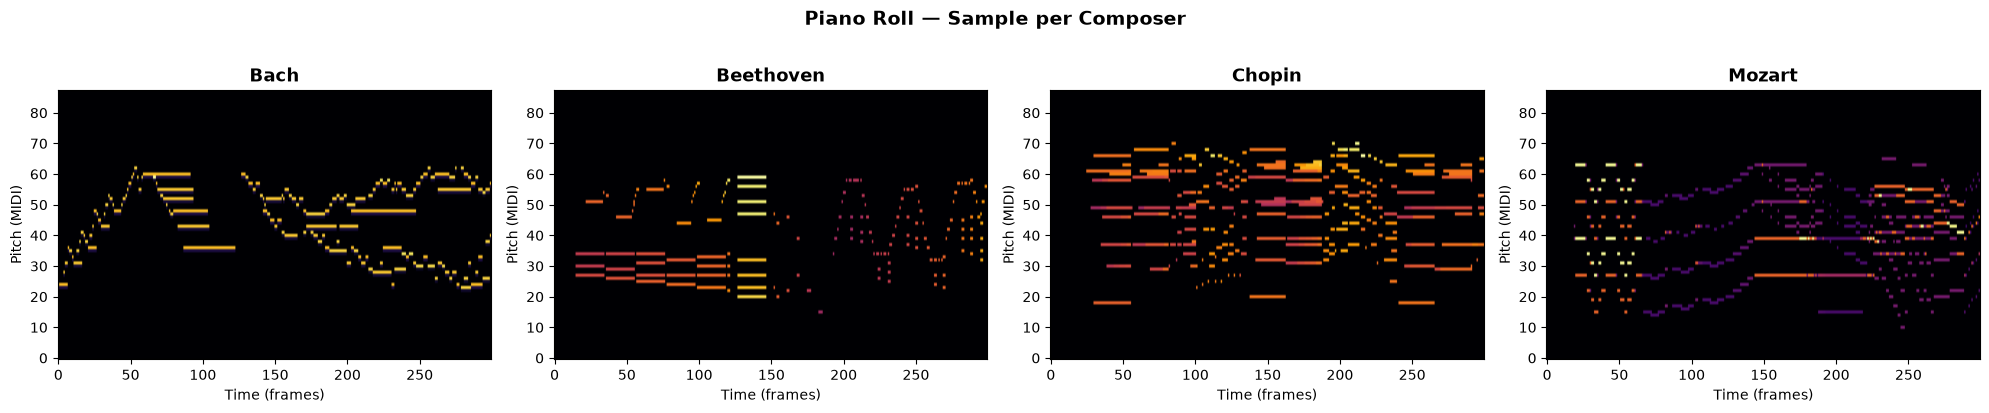

In [43]:
# 5. Piano Roll Visualization
composers_sample = COMPOSERS  # ['bach', 'beethoven', 'chopin', 'mozart']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, composer in zip(axes, composers_sample):
    folder = os.path.join(DATA_DIR, 'train', composer)
    midi_file = sorted(f for f in os.listdir(folder) if f.endswith('.mid'))[0]
    midi = pretty_midi.PrettyMIDI(os.path.join(folder, midi_file))
    roll = midi.get_piano_roll(fs=10)  # 10 frames per second
    roll = roll[21:109, :300]          # MIDI notes 21-108 (piano range), first 30s
    ax.imshow(roll, aspect='auto', origin='lower', cmap='inferno')
    ax.set_title(composer.capitalize(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (frames)')
    ax.set_ylabel('Pitch (MIDI)')

fig.suptitle('Piano Roll — Sample per Composer', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

---
## Phase 2 — Data Pre-processing & Feature Extraction

Note/chord sequence extraction and tempo (`pretty_midi`), vocabulary encoding, LSTM sliding windows, CNN piano-roll windows, pitch-shift + tempo-scale augmentation, and saving preprocessed arrays.

In [53]:
# Phase 2 imports & constants
import os
import json
import warnings
import statistics
import numpy as np
import pretty_midi


# Re-declare shared constants so this phase runs independently
DATA_DIR   = 'data'
COMPOSERS  = ['bach', 'beethoven', 'chopin', 'mozart']
splits     = ['train', 'dev', 'test']

WINDOW_SIZE     = 100
STEP_SIZE       = 10
FS              = 10
TIME_STEPS      = 128
CNN_STEP        = 32
PITCH_SHIFTS    = [-2, -1, 1, 2]     # semitone shifts for CNN augmentation
TEMPO_SCALES    = [0.9, 1.1]         # time-stretch factors for CNN augmentation (0.9=faster, 1.1=slower)

COMPOSER_TO_IDX = {c: i for i, c in enumerate(COMPOSERS)}
IDX_TO_COMPOSER = {i: c for c, i in COMPOSER_TO_IDX.items()}
print("Composer → label index:", COMPOSER_TO_IDX)

Composer → label index: {'bach': 0, 'beethoven': 1, 'chopin': 2, 'mozart': 3}


In [54]:
# 1. Note Sequence Extraction (+ tempo)

# extract_midi_features: read one MIDI file and return the features we need for
# modeling — the ordered list of note/chord tokens (for the LSTM) and the file's
# mean tempo in BPM (a descriptive feature). Returns a (notes, tempo) tuple.
def extract_midi_features(midi_path):
    try:
        midi   = pretty_midi.PrettyMIDI(midi_path)
        events = []
        for instr in midi.instruments:
            if instr.is_drum:
                continue
            for n in instr.notes:
                events.append((round(n.start, 3), pretty_midi.note_number_to_name(n.pitch)))
        events.sort(key=lambda e: e[0])

        notes_out = []
        i = 0
        while i < len(events):
            t0, name = events[i]
            chord = [name]
            j = i + 1
            while j < len(events) and abs(events[j][0] - t0) <= 0.05:
                chord.append(events[j][1])
                j += 1
            if len(chord) == 1:
                notes_out.append(chord[0])
            else:
                notes_out.append('.'.join(sorted(chord)))
            i = j

        tempi = midi.get_tempo_changes()[1]
        tempo = float(np.mean(tempi)) if len(tempi) else 120.0
        return notes_out, tempo
    except Exception as e:
        print(f"  Skipped {os.path.basename(midi_path)}: {e}")
        return [], 120.0

raw_sequences = {split: [] for split in splits}
tempo_records = []

for split in splits:
    print(f"\n{split}")
    for composer in COMPOSERS:
        folder = os.path.join(DATA_DIR, split, composer)
        files  = sorted(f for f in os.listdir(folder) if f.endswith('.mid'))
        ok = 0
        for fname in files:
            notes, tempo = extract_midi_features(os.path.join(folder, fname))
            if notes:
                raw_sequences[split].append((composer, notes))
                tempo_records.append((split, composer, tempo))
                ok += 1
        print(f"  {composer}: {ok}/{len(files)} files extracted")

print("\nExtraction complete.")
print("\nMean tempo per composer (train, BPM):")
for composer in COMPOSERS:
    tempi = [t for s, c, t in tempo_records if s == 'train' and c == composer]
    if tempi:
        print(f"  {composer:10s}: {np.mean(tempi):6.1f}  (n={len(tempi)})")


train
  bach: 42/42 files extracted
  beethoven: 42/42 files extracted
  chopin: 41/41 files extracted
  mozart: 41/41 files extracted

dev
  bach: 4/4 files extracted
  beethoven: 4/4 files extracted
  chopin: 4/4 files extracted
  mozart: 4/4 files extracted

test
  bach: 4/4 files extracted
  beethoven: 4/4 files extracted
  chopin: 4/4 files extracted
  mozart: 4/4 files extracted

Extraction complete.

Mean tempo per composer (train, BPM):
  bach      :  120.0  (n=42)
  beethoven :  118.4  (n=42)
  chopin    :  117.6  (n=41)
  mozart    :  110.0  (n=41)


In [55]:
# 2. Vocabulary & Integer Encoding  (built from train split only — no leakage)
# Tokens indexed from 1; 0 is reserved as OOV/mask for the LSTM Embedding.
all_train_notes = [n for _, notes in raw_sequences['train'] for n in notes]
vocab           = sorted(set(all_train_notes))
note_to_int     = {n: i + 1 for i, n in enumerate(vocab)}
int_to_note     = {i: n for n, i in note_to_int.items()}
vocab_size      = len(vocab)

print(f"Vocabulary size : {vocab_size} unique notes/chords (indices 1–{vocab_size}; 0 = OOV)")
print(f"Sample elements : {vocab[:10]}")

with open('vocab.json', 'w') as f:
    json.dump({
        'note_to_int': note_to_int,
        'int_to_note': {str(k): v for k, v in int_to_note.items()},
        'composers':   COMPOSERS
    }, f, indent=2)
print("Saved vocab.json")

Vocabulary size : 34760 unique notes/chords (indices 1–34760; 0 = OOV)
Sample elements : ['A#0.A#1.A#2', 'A#0.A#1.A#2.D#4.D#4.D#5.G4.G4.G5', 'A#0.A#1.G5.G6', 'A#1', 'A#1.A#1', 'A#1.A#1.A#1.A#2.A#2.A#3.A#3.A#4.A#4.G4.G4', 'A#1.A#1.A#2', 'A#1.A#1.A#2.A#2', 'A#1.A#1.A#2.A#2.A#2.A#2.A#3.A#3.A#3.A#3.A#3.A#4.A#4.A#4.A#4.A#4.A#5.A#5', 'A#1.A#1.A#2.A#2.A#2.A#2.A#3.A#3.A#3.A#4.A#4.A#4.A#4.A#5.A#5.A#5']
Saved vocab.json


In [56]:
# 3. LSTM Sliding Windows
def make_lstm_windows(sequences, note_to_int, window=WINDOW_SIZE, step=STEP_SIZE):
    """Convert (composer, notes) pairs into (X, y) arrays for LSTM classification."""
    X, y = [], []
    for composer, notes in sequences:
        encoded = [note_to_int.get(n, 0) for n in notes]  # 0 = out-of-vocabulary
        label   = COMPOSER_TO_IDX[composer]
        for i in range(0, len(encoded) - window, step):
            X.append(encoded[i : i + window])
            y.append(label)
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X_lstm, y_lstm = {}, {}
for split in splits:
    X_lstm[split], y_lstm[split] = make_lstm_windows(raw_sequences[split], note_to_int)
    print(f"{split:6s}  X={X_lstm[split].shape}  y={y_lstm[split].shape}")

print(f"\nInput shape per sample : ({WINDOW_SIZE},)  →  vocab_size={vocab_size}")

train   X=(25620, 100)  y=(25620,)
dev     X=(4249, 100)  y=(4249,)
test    X=(3215, 100)  y=(3215,)

Input shape per sample : (100,)  →  vocab_size=34760


In [57]:
# 4. CNN Piano-Roll Windows
def make_cnn_windows(data_dir, split, composers, composer_to_idx,
                     fs=FS, time_steps=TIME_STEPS, step=CNN_STEP):
    """Extract overlapping piano-roll windows from every MIDI file in a split."""
    X, y = [], []
    for composer in composers:
        folder = os.path.join(data_dir, split, composer)
        label  = composer_to_idx[composer]
        for fname in sorted(f for f in os.listdir(folder) if f.endswith('.mid')):
            try:
                roll  = pretty_midi.PrettyMIDI(os.path.join(folder, fname)).get_piano_roll(fs=fs)
                # Clip after dividing: overlapping notes can sum velocities above 127,
                # producing values > 1 if we only divide. Clip ensures [0, 1].
                roll  = np.clip(roll / 127.0, 0.0, 1.0)
                total = roll.shape[1]
                added = 0
                for start in range(0, total - time_steps + 1, step):
                    X.append(roll[:, start : start + time_steps])
                    y.append(label)
                    added += 1
                if added == 0:                              # file shorter than one window
                    pad = np.zeros((128, time_steps), dtype=np.float32)
                    pad[:, :total] = roll
                    X.append(pad)
                    y.append(label)
            except Exception as e:
                print(f"  Skipped {fname}: {e}")
    # add channel dim → (N, 128, TIME_STEPS, 1) for Conv2D
    return np.array(X, dtype=np.float32)[..., np.newaxis], np.array(y, dtype=np.int32)

X_cnn, y_cnn = {}, {}
for split in splits:
    X_cnn[split], y_cnn[split] = make_cnn_windows(DATA_DIR, split, COMPOSERS, COMPOSER_TO_IDX)
    print(f"{split:6s}  X={X_cnn[split].shape}  y={y_cnn[split].shape}")

print(f"\nInput shape per sample : (128, {TIME_STEPS}, 1)")

train   X=(16364, 128, 128, 1)  y=(16364,)
dev     X=(2340, 128, 128, 1)  y=(2340,)
test    X=(2033, 128, 128, 1)  y=(2033,)

Input shape per sample : (128, 128, 1)


In [58]:
# 5. Data Augmentation — pitch-shift + tempo-scale CNN training windows
def pitch_shift(sample, semitones):
    """Shift a (128, T, 1) piano-roll window up/down by `semitones` rows."""
    roll    = sample[:, :, 0]
    shifted = np.zeros_like(roll)
    if semitones > 0:
        shifted[semitones:, :] = roll[:-semitones, :]
    elif semitones < 0:
        shifted[:semitones, :] = roll[-semitones:, :]
    else:
        shifted = roll.copy()
    return shifted[..., np.newaxis]

def time_stretch(sample, factor):
    """Resample the time axis of a (128, T, 1) window by `factor`, then crop/pad
    back to T frames. factor<1 = faster (fewer source frames stretched out),
    factor>1 = slower. Simulates tempo variation."""
    roll  = sample[:, :, 0]
    T     = roll.shape[1]
    new_T = max(1, int(round(T * factor)))
    idx   = np.linspace(0, T - 1, new_T).astype(int)
    warped = roll[:, idx]
    out = np.zeros((128, T), dtype=roll.dtype)
    if new_T >= T:
        out[:] = warped[:, :T]          # crop back to T frames
    else:
        out[:, :new_T] = warped         # pad the tail with zeros
    return out[..., np.newaxis]

# Capture the ORIGINAL train windows before augmenting so we never augment
# already-augmented data.
base_X = list(X_cnn['train'])
base_y = list(y_cnn['train'])

X_aug = list(base_X)
y_aug = list(base_y)

# Pitch shifts over the base
for s in PITCH_SHIFTS:
    for x, lbl in zip(base_X, base_y):
        X_aug.append(pitch_shift(x, s))
        y_aug.append(lbl)

# Tempo scales over the base
for f in TEMPO_SCALES:
    for x, lbl in zip(base_X, base_y):
        X_aug.append(time_stretch(x, f))
        y_aug.append(lbl)

X_cnn['train'] = np.array(X_aug, dtype=np.float32)
y_cnn['train'] = np.array(y_aug, dtype=np.int32)

print(f"Pitch shifts applied : {PITCH_SHIFTS}")
print(f"Tempo scales applied : {TEMPO_SCALES}")
print(f"CNN train after augmentation: X={X_cnn['train'].shape}  y={y_cnn['train'].shape}")

Pitch shifts applied : [-2, -1, 1, 2]
Tempo scales applied : [0.9, 1.1]
CNN train after augmentation: X=(114548, 128, 128, 1)  y=(114548,)


In [59]:
# 6. Save preprocessed arrays
os.makedirs('preprocessed', exist_ok=True)

np.savez_compressed('preprocessed/lstm_data.npz',
    X_train = X_lstm['train'], y_train = y_lstm['train'],
    X_dev   = X_lstm['dev'],   y_dev   = y_lstm['dev'],
    X_test  = X_lstm['test'],  y_test  = y_lstm['test'])

np.savez_compressed('preprocessed/cnn_data.npz',
    X_train = X_cnn['train'],  y_train = y_cnn['train'],
    X_dev   = X_cnn['dev'],    y_dev   = y_cnn['dev'],
    X_test  = X_cnn['test'],   y_test  = y_cnn['test'])

print("Saved preprocessed/lstm_data.npz")
print(f"  train {X_lstm['train'].shape} | dev {X_lstm['dev'].shape} | test {X_lstm['test'].shape}")
print("Saved preprocessed/cnn_data.npz")
print(f"  train {X_cnn['train'].shape} | dev {X_cnn['dev'].shape} | test {X_cnn['test'].shape}")

Saved preprocessed/lstm_data.npz
  train (25620, 100) | dev (4249, 100) | test (3215, 100)
Saved preprocessed/cnn_data.npz
  train (114548, 128, 128, 1) | dev (2340, 128, 128, 1) | test (2033, 128, 128, 1)


---
## Phase 3 — LSTM Model

Embedding layer → stacked LSTM → Dense classifier.  
Trained on integer-encoded note/chord sequences (window = 100 tokens, vocab = 34,760).

In [60]:
# Phase 3 — LSTM Model (TensorFlow)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import json

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

lstm = np.load('preprocessed/lstm_data.npz')
X_train, y_train = lstm['X_train'], lstm['y_train']
X_dev,   y_dev   = lstm['X_dev'],   lstm['y_dev']
X_test,  y_test  = lstm['X_test'],  lstm['y_test']

with open('vocab.json') as f:
    _v = json.load(f)
vocab_size  = len(_v['note_to_int'])
n_composers = 4

Y_train = to_categorical(y_train, n_composers)
Y_dev   = to_categorical(y_dev,   n_composers)
Y_test  = to_categorical(y_test,  n_composers)

print(f"Train : {X_train.shape}  |  Dev : {X_dev.shape}  |  Test : {X_test.shape}")
print(f"vocab_size={vocab_size}, n_composers={n_composers}")

EMBED_DIM  = 64
LSTM1      = 256
LSTM2      = 128
DENSE1     = 64
DROPOUT    = 0.3
BATCH_SIZE = 256
MAX_EPOCHS = 100

model_lstm = Sequential([
    Embedding(input_dim=vocab_size + 1, output_dim=EMBED_DIM,
              input_length=X_train.shape[1], mask_zero=True),
    LSTM(LSTM1, return_sequences=True),
    Dropout(DROPOUT),
    LSTM(LSTM2),
    Dense(DENSE1, activation='relu'),
    Dropout(DROPOUT),
    Dense(n_composers, activation='softmax'),
], name='lstm_composer')

model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_lstm.summary()

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('preprocessed/lstm_best.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
]

history_lstm = model_lstm.fit(
    X_train, Y_train,
    validation_data=(X_dev, Y_dev),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

_, dev_acc  = model_lstm.evaluate(X_dev,  Y_dev,  verbose=0)
_, test_acc = model_lstm.evaluate(X_test, Y_test, verbose=0)
print(f"\nDev  accuracy : {dev_acc:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

Train : (25620, 100)  |  Dev : (4249, 100)  |  Test : (3215, 100)
vocab_size=34760, n_composers=4


Model: "lstm_composer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 46s 443ms/step - accuracy: 0.7260 - loss: 0.6966 - val_accuracy: 0.5368 - val_loss: 1.6362
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step - accuracy: 0.9642 - loss: 0.1341 - val_accuracy: 0.5378 - val_loss: 1.7305
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step - accuracy: 0.9858 - loss: 0.0572 - val_accuracy: 0.5451 - val_loss: 2.3787
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 447ms/step - accuracy: 0.9946 - loss: 0.0239 - val_accuracy: 0.5413 - val_loss: 2.2796
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step - accuracy: 0.9927 - loss: 0.0271 - val_accuracy: 0.5239 - val_loss: 2.6255
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 46s 451ms/step - accuracy: 0.9878 - loss: 0.0468 - val_accuracy: 0.5265 - val_loss: 2.5192
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 464ms/step - accuracy: 0.9952 - loss: 0.0244 - val_accuracy: 0.4801 - val_loss: 3.4856
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9983 - l

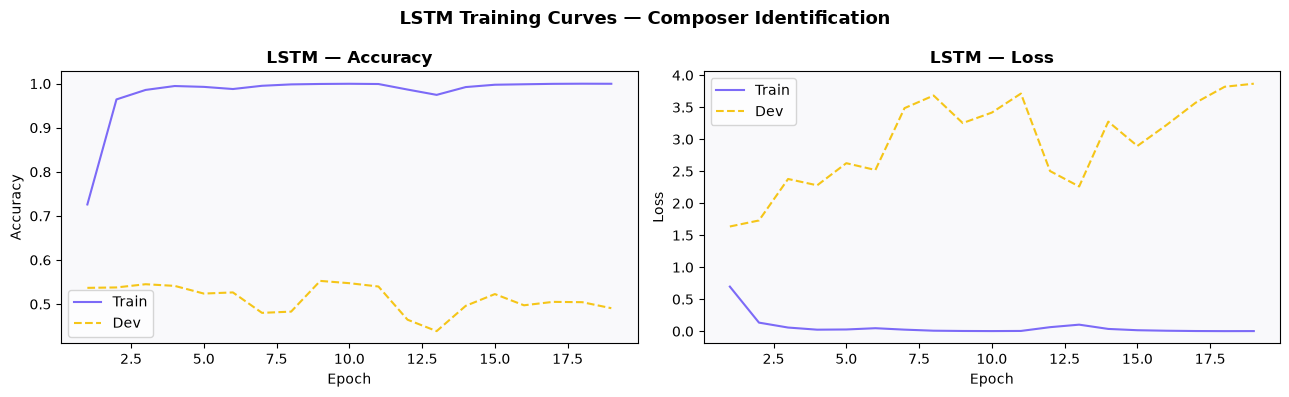

In [61]:
# Phase 3 — Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(history_lstm.history['accuracy']) + 1)

ax1.plot(epochs, history_lstm.history['accuracy'],     label='Train', color='#7c6af7')
ax1.plot(epochs, history_lstm.history['val_accuracy'], label='Dev',   color='#f5c518', linestyle='--')
ax1.set_title('LSTM — Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_facecolor('#f9f9fb')

ax2.plot(epochs, history_lstm.history['loss'],     label='Train', color='#7c6af7')
ax2.plot(epochs, history_lstm.history['val_loss'], label='Dev',   color='#f5c518', linestyle='--')
ax2.set_title('LSTM — Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.set_facecolor('#f9f9fb')

fig.suptitle('LSTM Training Curves — Composer Identification', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

---
## Phase 4 — CNN Model

2D CNN treating piano-roll windows as grayscale images (128 pitches × 128 frames × 1 channel).  
Trained on 114,548 augmented windows (7× pitch-shift + tempo-scale augmentation).